# JFK daily temperature & monthly degree days
Two NOAA observation versions: **GHCN-Daily USW00094789** and **Aviation Weather METAR KJFK**.

History starts **2000-01-01**; base **65°F**. Forecast snapshots are archived every six hours separately from observations.

GHCN has the long historical record. The Aviation Weather API exposes up to 30 recent days, so its direct version cannot recreate the 2000–present record. The archive grows forward from today. Neither observation feed supplies temperature forecasts: we retain NOAA/NWS hourly gridded forecasts near JFK and aviation TAF forecasts.

Run with the project's `.venv` Python. By default this notebook uses downloaded files without network access.

In [1]:
from pathlib import Path
import os
os.environ.setdefault('MPLCONFIGDIR', str(Path.cwd() / '.mplconfig'))
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
import weather_pipeline as w
pd.set_option('display.max_columns', 12)
plt.rcParams.update({'figure.figsize': (12, 4), 'axes.spines.top': False, 'axes.spines.right': False})
print({'station': w.ICAO, 'ghcn_id': w.GHCN_ID, 'start': w.START, 'base_f': w.BASE_F, 'timezone': w.TZ})

Matplotlib is building the font cache; this may take a moment.


{'station': 'KJFK', 'ghcn_id': 'USW00094789', 'start': '2000-01-01', 'base_f': 65.0, 'timezone': 'America/New_York'}


/Users/stevenxu/Documents/ChatGPT/Weather Derivative/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## 1. Download and preserve source data
Set the switches to `True` to refresh. Each response is retained with retrieval time, URL, headers, and SHA-256. Forecast runs keep independent snapshots and a manifest; a partial failure raises an error while preserving successful products. TAFs are aviation forecasts, not hourly temperature forecasts.

In [2]:
REFRESH_OBSERVATIONS = False
ARCHIVE_FORECAST_NOW = False
if ARCHIVE_FORECAST_NOW:
    w.archive_forecasts()
if REFRESH_OBSERVATIONS:
    w.refresh_observations()

## 2. Clean both daily versions
**GHCN:** parse tenths of °C; reject `-9999` and nonblank NOAA quality flags. Retain measurement/source flags in the audit CSV. Reject reversed extrema and leave gaps unfilled. Temperature is `(TMAX + TMIN) / 2` on NOAA's reported date; historical observing-day conventions may differ from a local calendar day.

**METAR:** keep the latest receipt for duplicate observation times; retain raw reports and QC fields. Apply a broad −60 to 55°C plausibility screen (not equivalent to NOAA climate QC). Average reports within each UTC hour to reduce extra SPECI report weighting. Convert to America/New_York dates, accounting for 23/25-hour DST days. Require every local hourly bin and a finished local day before accepting the daily index. Use the midpoint of the sampled hourly extrema; also export the hourly mean as a diagnostic. Sampled extrema may miss true extremes, so these versions are not interchangeable.

In [3]:
ghcn, metar, comparison = w.build()
summary = pd.DataFrame([
    {'version': name, 'first_date': f.index.min().date(), 'last_date': f.index.max().date(),
     'calendar_rows': len(f), 'accepted_days': int(f.valid_day.sum()), 'missing_or_rejected': int((~f.valid_day).sum())}
    for name, f in [('GHCN-Daily', ghcn), ('METAR', metar)]])
display(summary)
display(ghcn.tail(7))
display(metar.tail(7))

,version,first_date,last_date,calendar_rows,accepted_days,missing_or_rejected
0,GHCN-Daily,2000-01-01,2026-09-16,9756,9755,1
1,METAR,2026-08-18,2026-09-17,31,27,4


element,tmax_c,tmin_c,valid_day,tmean_c,source,tmean_f,hdd65_f_days,cdd65_f_days
date,,,,,,,,
2026-09-10,31.1,22.2,True,26.65,GHCN-Daily,79.97,0.00,14.97
2026-09-11,26.1,18.9,True,22.50,GHCN-Daily,72.50,0.00,7.50
2026-09-12,25.0,16.7,True,20.85,GHCN-Daily,69.53,0.00,4.53
2026-09-13,26.7,21.7,True,24.20,GHCN-Daily,75.56,0.00,10.56
2026-09-14,25.0,16.7,True,20.85,GHCN-Daily,69.53,0.00,4.53
2026-09-15,21.1,13.3,True,17.20,GHCN-Daily,62.96,2.04,0.00
2026-09-16,NaN,NaN,False,NaN,GHCN-Daily,NaN,NaN,NaN


,tmin_c,tmax_c,sampled_hourly_mean_c,observed_hours,expected_hours,coverage,valid_day,tmean_c,source,tmean_f,hdd65_f_days,cdd65_f_days
date,,,,,,,,,,,,
2026-09-11,19.4,26.1,23.379167,24,24,1.000000,True,22.75,METAR sampled hourly extrema,72.95,0.00,7.95
2026-09-12,16.7,25.0,21.421739,23,24,0.958333,False,NaN,METAR sampled hourly extrema,NaN,NaN,NaN
2026-09-13,21.7,26.7,23.237500,24,24,1.000000,True,24.20,METAR sampled hourly extrema,75.56,0.00,10.56
2026-09-14,16.7,25.0,22.245833,24,24,1.000000,True,20.85,METAR sampled hourly extrema,69.53,0.00,4.53
2026-09-15,14.4,21.1,17.900000,24,24,1.000000,True,17.75,METAR sampled hourly extrema,63.95,1.05,0.00
2026-09-16,15.6,24.4,20.683333,24,24,1.000000,True,20.00,METAR sampled hourly extrema,68.00,0.00,3.00
2026-09-17,21.1,26.7,23.400000,17,24,0.708333,False,NaN,METAR sampled hourly extrema,NaN,NaN,NaN


## 3. Monthly heating and cooling indices
For each accepted day, `HDD65 = max(65 − Tmean_F, 0)` and `CDD65 = max(Tmean_F − 65, 0)`, in **°F-days**. Sum daily values, not monthly mean temperatures. Published monthly indices require all calendar days, including leap days. `hdd_partial` and `cdd_partial` show available-day sums with coverage; they are not full-month totals and are never scaled or imputed.

In [4]:
ghcn_monthly = w.monthly(ghcn)
metar_monthly = w.monthly(metar)
display(ghcn_monthly.tail(15).round(2))
display(metar_monthly.round(2))

,valid_days,hdd_partial,cdd_partial,calendar_days,coverage,complete_month,hdd65_f_days,cdd65_f_days
month,,,,,,,,
2025-07,31,0.00,460.92,31,1.0,True,0.00,460.92
2025-08,31,0.00,240.78,31,1.0,True,0.00,240.78
2025-09,30,6.96,141.24,30,1.0,True,6.96,141.24
2025-10,31,219.33,15.60,31,1.0,True,219.33,15.60
2025-11,30,550.62,0.00,30,1.0,True,550.62,0.00
2025-12,31,977.64,0.00,31,1.0,True,977.64,0.00
2026-01,31,1092.57,0.00,31,1.0,True,1092.57,0.00
2026-02,28,982.68,0.00,28,1.0,True,982.68,0.00
2026-03,31,680.37,0.00,31,1.0,True,680.37,0.00


,valid_days,hdd_partial,cdd_partial,calendar_days,coverage,complete_month,hdd65_f_days,cdd65_f_days
month,,,,,,,,
2026-08,13,0.00,114.15,31,0.42,False,NaN,NaN
2026-09,14,1.05,111.40,30,0.47,False,NaN,NaN


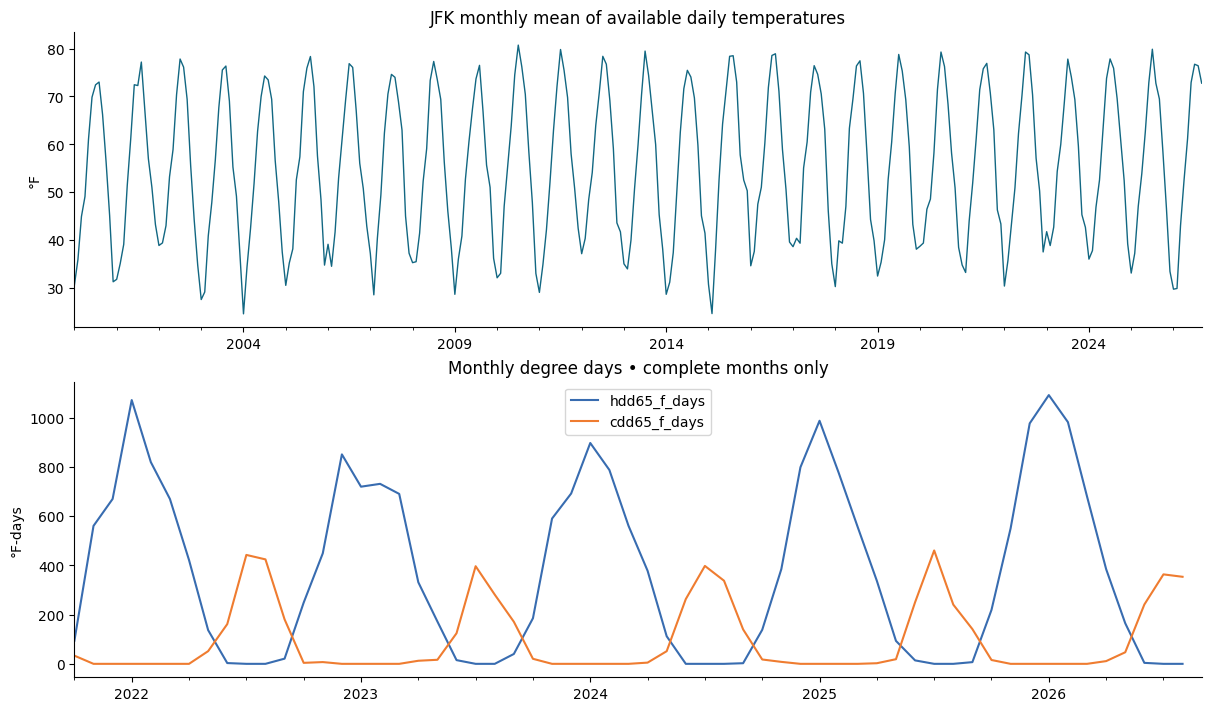

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), constrained_layout=True)
ghcn.tmean_f.resample('MS').mean().plot(ax=axes[0], color='#126782', lw=1)
axes[0].set(title='JFK monthly mean of available daily temperatures', ylabel='°F', xlabel='')
p = ghcn_monthly[['hdd65_f_days', 'cdd65_f_days']].copy()
p.index = p.index.to_timestamp()
p.tail(60).plot(ax=axes[1], color=['#386cb0', '#ef7c30'])
axes[1].set(title='Monthly degree days • complete months only', ylabel='°F-days', xlabel='')
plt.show()

## 4. Compare overlapping days
The difference combines observation timing, sampling, and source-processing effects. No bias correction is applied. GHCN reporting latency can reduce the overlap.

Paired accepted days: 26


,tmean_c_ghcn,tmean_c_metar,difference_c
date,,,
2026-08-19,25.55,25.55,-0.00
2026-08-20,23.30,23.30,0.00
2026-08-21,21.95,21.70,-0.25
2026-08-22,23.30,22.20,-1.10
2026-08-23,23.90,23.60,-0.30
2026-08-24,22.75,23.05,0.30
2026-08-25,22.50,22.50,0.00
2026-08-26,22.80,22.80,0.00
2026-08-27,23.60,23.90,0.30


mean_METAR_minus_GHCN_C    0.037500
MAE_C                      0.164423
RMSE_C                     0.292741
dtype: float64

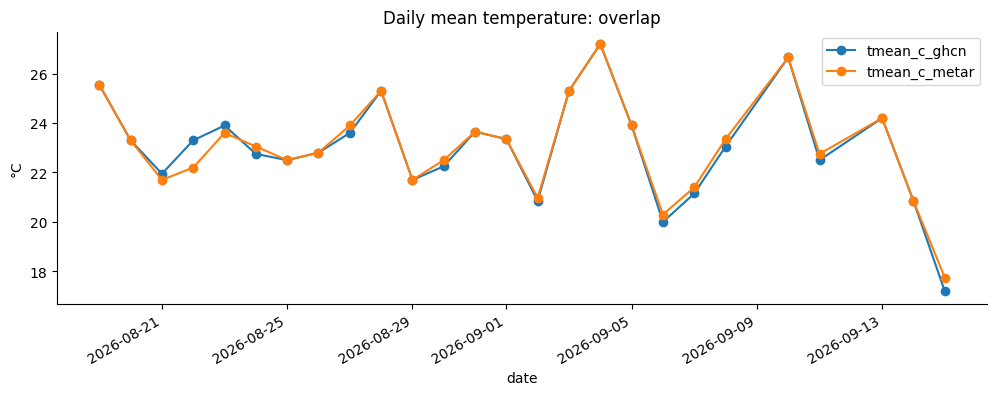

In [6]:
paired = comparison.dropna()
print(f'Paired accepted days: {len(paired)}')
if len(paired):
    display(paired.round(2))
    display(pd.Series({'mean_METAR_minus_GHCN_C': paired.difference_c.mean(),
                       'MAE_C': paired.difference_c.abs().mean(),
                       'RMSE_C': (paired.difference_c.pow(2).mean())**0.5}))
    paired[['tmean_c_ghcn', 'tmean_c_metar']].plot(marker='o', ylabel='°C', title='Daily mean temperature: overlap')
    plt.show()

## 5. Forecast archive
Each six-hour run saves the entire available NWS hourly horizon and current TAF, plus 48 hours of METAR for continued observation coverage. Retrieval, forecast update/generation, and valid times remain distinct. NWS is a grid forecast near JFK, not a station-issued thermometer forecast. The scheduler depends on the Codex desktop host being available; missed snapshots cannot be reconstructed from the current forecast endpoint.

In [7]:
import json
runs = sorted((w.ROOT / 'data/forecasts').glob('*/manifest.json'))
status = []
for path in runs:
    m = json.loads(path.read_text())
    status.append({'retrieved_utc': m['started_at_utc'], 'products': ', '.join(m['products']), 'errors': str(m['errors'])})
display(pd.DataFrame(status))
latest = sorted((w.ROOT / 'data/forecasts').glob('*/nws_hourly.csv'))[-1]
forecast = pd.read_csv(latest)
display(forecast[['startTime', 'endTime', 'temperature', 'temperatureUnit', 'update_time_utc', 'lead_hours_at_retrieval']].head(12))
print('Latest forecast archive:', latest.parent)

,retrieved_utc,products,errors
0,2026-09-17T21:00:10.430523+00:00,"nws_hourly, taf, metar",{}


,startTime,endTime,temperature,temperatureUnit,update_time_utc,lead_hours_at_retrieval
0,2026-09-17T17:00:00-04:00,2026-09-17T18:00:00-04:00,75,F,2026-09-17T18:41:02+00:00,-0.107304
1,2026-09-17T18:00:00-04:00,2026-09-17T19:00:00-04:00,75,F,2026-09-17T18:41:02+00:00,0.892696
2,2026-09-17T19:00:00-04:00,2026-09-17T20:00:00-04:00,74,F,2026-09-17T18:41:02+00:00,1.892696
3,2026-09-17T20:00:00-04:00,2026-09-17T21:00:00-04:00,74,F,2026-09-17T18:41:02+00:00,2.892696
4,2026-09-17T21:00:00-04:00,2026-09-17T22:00:00-04:00,74,F,2026-09-17T18:41:02+00:00,3.892696
5,2026-09-17T22:00:00-04:00,2026-09-17T23:00:00-04:00,74,F,2026-09-17T18:41:02+00:00,4.892696
6,2026-09-17T23:00:00-04:00,2026-09-18T00:00:00-04:00,74,F,2026-09-17T18:41:02+00:00,5.892696
7,2026-09-18T00:00:00-04:00,2026-09-18T01:00:00-04:00,73,F,2026-09-17T18:41:02+00:00,6.892696
8,2026-09-18T01:00:00-04:00,2026-09-18T02:00:00-04:00,73,F,2026-09-17T18:41:02+00:00,7.892696
9,2026-09-18T02:00:00-04:00,2026-09-18T03:00:00-04:00,74,F,2026-09-17T18:41:02+00:00,8.892696


Latest forecast archive: /Users/stevenxu/Documents/ChatGPT/Weather Derivative/data/forecasts/20260917T210625497227Z_8bdaec


## Outputs and references
Daily and monthly tables, retained observations, quality audit, and source comparison are in `data/processed/`. Immutable source responses are in `data/raw/`; forecast snapshots are in `data/forecasts/`.

- [NOAA GHCN-Daily format and quality flags](https://www.ncei.noaa.gov/pub/data/ghcn/daily/readme.txt)
- [NOAA station metadata](https://www.ncei.noaa.gov/pub/data/ghcn/daily/ghcnd-stations.txt)
- [Aviation Weather API](https://aviationweather.gov/data/api/)
- [NWS API documentation](https://www.weather.gov/documentation/services-web-api)

Station metadata and API schema consulted for this build are retained in `data/reference/`.